In [1]:
!pip install pandas matplotlib

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [4]:
data = {
    "road": ["Road A", "Road B", "Road C", "Road D"],
    "vehicles": [120, 40, 75, 20],
    "capacity": [50, 60, 50, 40]
}

traffic_df = pd.DataFrame(data)

traffic_df

,road,vehicles,capacity
0,Road A,120,50
1,Road B,40,60
2,Road C,75,50
3,Road D,20,40


In [5]:
traffic_df["congestion"] = traffic_df["vehicles"] > traffic_df["capacity"]

traffic_df["congestion"] = traffic_df["congestion"].map({True: "Yes", False: "No"})

traffic_df

,road,vehicles,capacity,congestion
0,Road A,120,50,Yes
1,Road B,40,60,No
2,Road C,75,50,Yes
3,Road D,20,40,No


In [6]:
traffic_df["batches"] = traffic_df.apply(
    lambda row: math.ceil(row["vehicles"] / row["capacity"]),
    axis=1
)

traffic_df

,road,vehicles,capacity,congestion,batches
0,Road A,120,50,Yes,3
1,Road B,40,60,No,1
2,Road C,75,50,Yes,2
3,Road D,20,40,No,1


In [7]:
def generate_schedule(vehicles, capacity):
    
    batches = math.ceil(vehicles / capacity)
    
    schedule = []
    
    remaining = vehicles
    
    for i in range(1, batches + 1):
        
        batch_size = min(capacity, remaining)
        
        schedule.append({
            "batch": i,
            "vehicles": batch_size,
            "time_slot": f"{(i-1)*2}-{i*2} minutes"
        })
        
        remaining -= batch_size
        
    return schedule

In [8]:
generate_schedule(120, 50)

[{'batch': 1, 'vehicles': 50, 'time_slot': '0-2 minutes'},
 {'batch': 2, 'vehicles': 50, 'time_slot': '2-4 minutes'},
 {'batch': 3, 'vehicles': 20, 'time_slot': '4-6 minutes'}]

In [9]:
for index, row in traffic_df.iterrows():
    
    print("\nTraffic Plan for", row["road"])
    
    schedule = generate_schedule(row["vehicles"], row["capacity"])
    
    for s in schedule:
        print(
            "Batch", s["batch"],
            "| Vehicles:", s["vehicles"],
            "| Time:", s["time_slot"]
        )


Traffic Plan for Road A
Batch 1 | Vehicles: 50 | Time: 0-2 minutes
Batch 2 | Vehicles: 50 | Time: 2-4 minutes
Batch 3 | Vehicles: 20 | Time: 4-6 minutes

Traffic Plan for Road B
Batch 1 | Vehicles: 40 | Time: 0-2 minutes

Traffic Plan for Road C
Batch 1 | Vehicles: 50 | Time: 0-2 minutes
Batch 2 | Vehicles: 25 | Time: 2-4 minutes

Traffic Plan for Road D
Batch 1 | Vehicles: 20 | Time: 0-2 minutes


In [10]:
def suggest_route(df):
    
    clear_roads = df[df["congestion"] == "No"]
    
    if len(clear_roads) == 0:
        return "No alternate routes available"
    
    best = clear_roads.sort_values("vehicles").iloc[0]
    
    return best["road"]

print("Suggested Alternate Route:", suggest_route(traffic_df))

Suggested Alternate Route: Road D


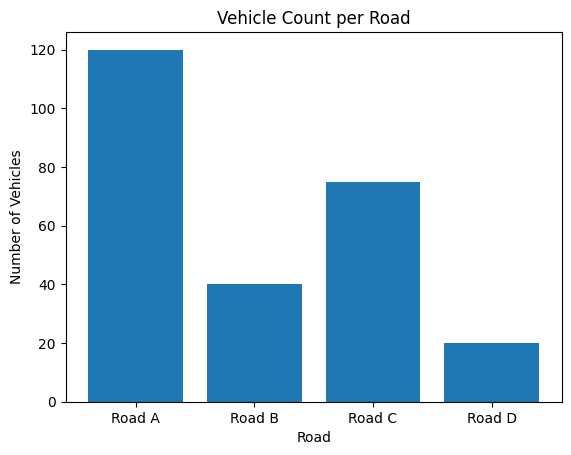

In [11]:
plt.bar(traffic_df["road"], traffic_df["vehicles"])

plt.title("Vehicle Count per Road")

plt.xlabel("Road")

plt.ylabel("Number of Vehicles")

plt.show()

In [12]:
traffic_df.to_csv("traffic_data.csv", index=False)

In [15]:
def traffic_level(row):
    
    ratio = row["vehicles"] / row["capacity"]
    
    if ratio <= 0.5:
        return "Low"
    
    elif ratio <= 1:
        return "Moderate"
    
    else:
        return "High"

In [16]:
traffic_df["traffic_level"] = traffic_df.apply(traffic_level, axis=1)

traffic_df

,road,vehicles,capacity,congestion,batches,traffic_level
0,Road A,120,50,Yes,3,High
1,Road B,40,60,No,1,Moderate
2,Road C,75,50,Yes,2,High
3,Road D,20,40,No,1,Low


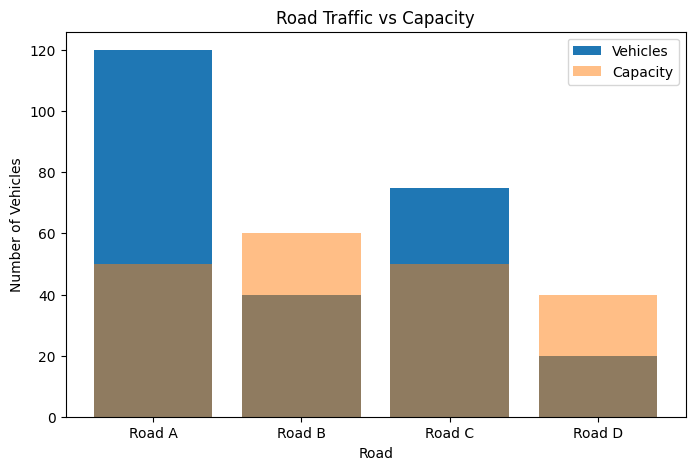

In [17]:
plt.figure(figsize=(8,5))

plt.bar(traffic_df["road"], traffic_df["vehicles"], label="Vehicles")
plt.bar(traffic_df["road"], traffic_df["capacity"], alpha=0.5, label="Capacity")

plt.title("Road Traffic vs Capacity")

plt.xlabel("Road")
plt.ylabel("Number of Vehicles")

plt.legend()

plt.show()

In [18]:
most_congested = traffic_df.sort_values("vehicles", ascending=False).iloc[0]

print("Most Congested Road:", most_congested["road"])
print("Vehicles:", most_congested["vehicles"])

Most Congested Road: Road A
Vehicles: 120


In [19]:
traffic_df["load_ratio"] = traffic_df["vehicles"] / traffic_df["capacity"]

traffic_df.sort_values("load_ratio", ascending=False)

,road,vehicles,capacity,congestion,batches,traffic_level,load_ratio
0,Road A,120,50,Yes,3,High,2.400000
2,Road C,75,50,Yes,2,High,1.500000
1,Road B,40,60,No,1,Moderate,0.666667
3,Road D,20,40,No,1,Low,0.500000


In [22]:
traffic_df.to_csv("traffic_data.csv", index=False)

In [24]:
!pip install networkx

In [25]:
import networkx as nx

In [26]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("B","C"),
    ("A","D"),
    ("D","E"),
    ("B","E")
])

print(G.edges())

[('A', 'B'), ('A', 'D'), ('B', 'C'), ('B', 'E'), ('D', 'E')]


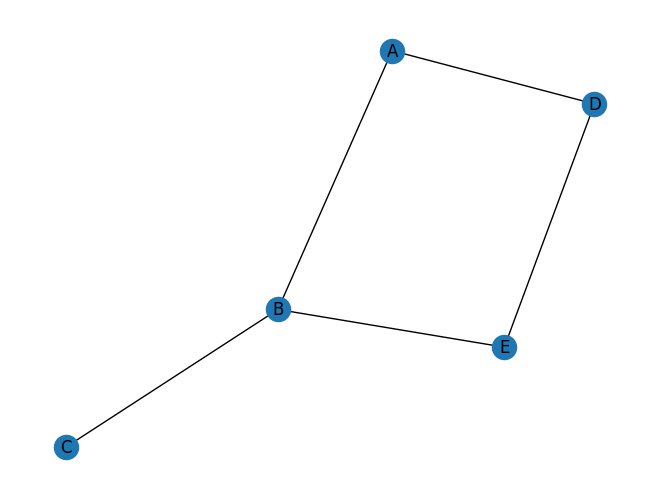

In [27]:
nx.draw(G, with_labels=True)

plt.show()

In [28]:
weights = {
    ("A","B"):5,
    ("B","C"):3,
    ("A","D"):2,
    ("D","E"):1,
    ("B","E"):4
}

for edge, weight in weights.items():
    G[edge[0]][edge[1]]["weight"] = weight

In [29]:
path = nx.shortest_path(G, source="A", target="C", weight="weight")

print("Best Route:", path)

Best Route: ['A', 'B', 'C']


In [30]:
cost = nx.shortest_path_length(G, source="A", target="C", weight="weight")

print("Total Traffic Cost:", cost)

Total Traffic Cost: 8


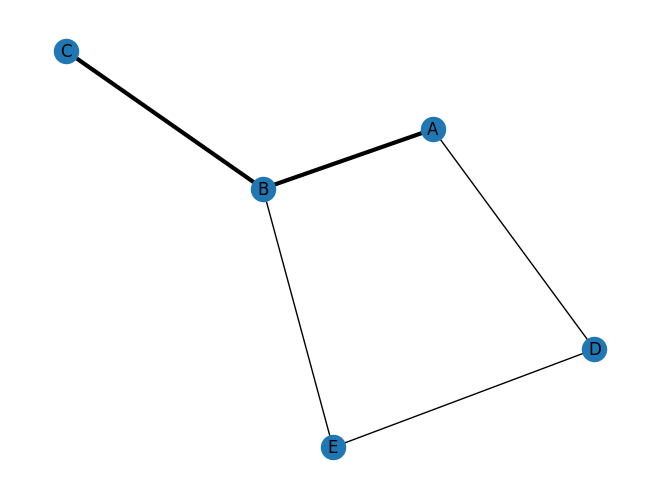

In [31]:
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=list(zip(path, path[1:])),
    width=3
)

plt.show()

In [32]:
def detect_emergency(vehicle_type):
    
    emergency_vehicles = ["ambulance", "police", "fire_truck"]
    
    if vehicle_type.lower() in emergency_vehicles:
        return True
    else:
        return False

In [33]:
vehicle = "ambulance"

if detect_emergency(vehicle):
    print("Emergency vehicle detected")
else:
    print("Normal vehicle")

Emergency vehicle detected


In [34]:
def emergency_route(graph, start, end):
    
    path = nx.shortest_path(graph, source=start, target=end)
    
    return path

In [35]:
route = emergency_route(G, "A", "C")

print("Emergency Priority Route:", route)

Emergency Priority Route: ['A', 'B', 'C']


In [36]:
vehicle_type = "ambulance"

start = "A"
destination = "C"

if detect_emergency(vehicle_type):
    
    route = emergency_route(G, start, destination)
    
    print("🚑 Emergency Priority Activated")
    print("Route:", route)

else:
    
    route = nx.shortest_path(G, source=start, target=destination, weight="weight")
    
    print("Normal Route:", route)

🚑 Emergency Priority Activated
Route: ['A', 'B', 'C']


In [37]:
for index, row in traffic_df.iterrows():
    
    print("\nRoad:", row["road"])
    print("Vehicles:", row["vehicles"])
    print("Capacity:", row["capacity"])
    print("Traffic Level:", row["traffic_level"])


Road: Road A
Vehicles: 120
Capacity: 50
Traffic Level: High

Road: Road B
Vehicles: 40
Capacity: 60
Traffic Level: Moderate

Road: Road C
Vehicles: 75
Capacity: 50
Traffic Level: High

Road: Road D
Vehicles: 20
Capacity: 40
Traffic Level: Low


In [1]:
def generate_vehicle_tokens(vehicles, capacity):

    tokens = []

    batch = 1
    time = 0

    for i in range(vehicles):

        tokens.append({
            "vehicle_id": f"V{i+1}",
            "batch": batch,
            "time_slot": f"{time}-{time+2} min"
        })

        if (i+1) % capacity == 0:
            batch += 1
            time += 2

    return tokens